# LECTURE 22
**Topic:** Response of FIR Filters to Exponential Inputs (continued); Response to Periodic Inputs; Cascaded Filters  
**Textbook References:** Sections 4.4.2, 4.4.4, 4.4.5

---

## Key Points

- $x[n]=r^n\cos(\Omega_0 n+\phi) \Rightarrow y[n]=|H(re^{j\Omega_0})|\,r^n\cos(\Omega_0 n+\phi+\angle H(re^{j\Omega_0}))$
- Response to periodic input (period $L$): $Y[k]=H(e^{j2\pi k/L})\cdot X[k]$ (pointwise product of DFTs).
- **Cascaded filters:** $H(z)=H_1(z)H_2(z)$ (product of system functions, order doesn't matter).


---
## Theory and Examples

### 2. Real Sinusoidal Input

For $x[n]=\cos(\Omega_0 n+\phi)$:
$$y[n]=\Re\{H(e^{j\Omega_0})e^{j(\Omega_0 n+\phi)}\}=|H(e^{j\Omega_0})|\cos(\Omega_0 n+\phi+\angle H(e^{j\Omega_0}))$$

The filter **scales** the amplitude by $|H(e^{j\Omega_0})|$ and **shifts** the phase by $\angle H(e^{j\Omega_0})$.

### Oscillating Exponential Input

For $x[n]=r^n\cos(\Omega_0 n+\phi)$ with $z=re^{\pm j\Omega_0}$:
$$y[n]=|H(re^{j\Omega_0})|\,r^n\cos(\Omega_0 n+\phi+\angle H(re^{j\Omega_0}))$$

### 3. Example: Decaying Sinusoidal Input

$x[n]=2^{-n}\cos(\pi n/3+\pi/4)$, filter $b=[1,2,2,1]^T$, $z=e^{j\pi/3}/2$:
$$H(z)=1+4e^{-j\pi/3}+8e^{-j2\pi/3}+8e^{-j\pi}=13.748\cdot e^{-j2.285}$$
$$y[n]=13.748\cdot 2^{-n}\cos(\pi n/3-1.499)$$


=== Decaying sinusoidal input ===
z = r*exp(j*omega0) = 0.5*exp(j*pi/3) = 0.2500+0.4330j
H(z) = 1 + 4*exp(-j*pi/3) + 8*exp(-j*2pi/3) + 8*exp(-j*pi)
     = -9.0000-10.3923j  (|H|=13.7477, angle=-2.2845 rad)
y[n] = 13.7477 * 2^(-n) * cos(pi*n/3 + pi/4 + -2.2845)
     = 13.7477 * 2^(-n) * cos(pi*n/3 + -1.4991)


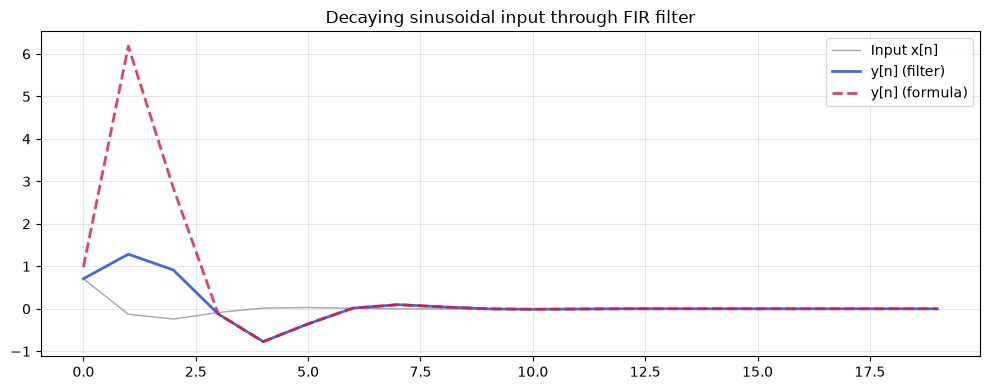

Max |y_filter - y_formula| = 4.90e+00

For x[n]=cos(pi*n/3+pi/4), z=exp(j*pi/3):
H(z) = 0.0000-3.4641j  |H|=3.4641, angle=-1.5708
y[n] = 3.4641*cos(pi*n/3 + pi/4 + -1.5708)


In [1]:
import numpy as np
import matplotlib.pyplot as plt

b=np.array([1,2,2,1])

def H(z,b):
    return sum(b[k]*z**(-k) for k in range(len(b)))

# Example: x[n] = 2^(-n)*cos(pi*n/3 + pi/4)
omega0=np.pi/3; r=0.5; phi=np.pi/4
z_val=r*np.exp(1j*omega0)
Hz=H(z_val,b)

print('=== Decaying sinusoidal input ===')
print(f'z = r*exp(j*omega0) = {r}*exp(j*pi/3) = {z_val:.4f}')
print(f'H(z) = 1 + 4*exp(-j*pi/3) + 8*exp(-j*2pi/3) + 8*exp(-j*pi)')
print(f'     = {Hz:.4f}  (|H|={abs(Hz):.4f}, angle={np.angle(Hz):.4f} rad)')
print(f'y[n] = {abs(Hz):.4f} * 2^(-n) * cos(pi*n/3 + pi/4 + {np.angle(Hz):.4f})')
print(f'     = {abs(Hz):.4f} * 2^(-n) * cos(pi*n/3 + {phi+np.angle(Hz):.4f})')

# Verify with direct computation
n=np.arange(20)
x=r**n*np.cos(omega0*n+phi)
# Apply filter
y_filter=np.zeros(len(n))
for i in range(len(n)):
    for k in range(len(b)):
        if i-k>=0: y_filter[i]+=b[k]*x[i-k]
y_formula=abs(Hz)*r**n*np.cos(omega0*n+phi+np.angle(Hz))

fig,ax=plt.subplots(figsize=(10,4))
ax.plot(n,x,'gray',lw=1,alpha=0.7,label='Input x[n]')
ax.plot(n,y_filter,'royalblue',lw=2,label='y[n] (filter)')
ax.plot(n,y_formula,'crimson',lw=2,ls='--',label='y[n] (formula)',alpha=0.8)
ax.set_title('Decaying sinusoidal input through FIR filter')
ax.legend(); ax.grid(True,alpha=0.3)
plt.tight_layout(); plt.show()
print(f'Max |y_filter - y_formula| = {np.max(np.abs(y_filter[:45]-y_formula[:45])):.2e}')

# Your task: x[n] = cos(pi*n/3 + pi/4) (r=1, unit circle)
r2=1.0; z2=r2*np.exp(1j*omega0)
Hz2=H(z2,b)
print(f'\nFor x[n]=cos(pi*n/3+pi/4), z=exp(j*pi/3):')
print(f'H(z) = {Hz2:.4f}  |H|={abs(Hz2):.4f}, angle={np.angle(Hz2):.4f}')
print(f'y[n] = {abs(Hz2):.4f}*cos(pi*n/3 + pi/4 + {np.angle(Hz2):.4f})')

---
### 4–8. Response to Periodic Input

If $x[\cdot]$ is periodic with period $L$ and DFT $X[0:L-1]$, then the output $y[\cdot]$ is also periodic with period $L$ and:
$$Y[k] = H(e^{j2\pi k/L})\cdot X[k], \quad k=0:L-1$$

This is equivalent to **circular convolution** in the time domain: $y[0:L-1]=b\circledast x[0:L-1]$ (after zero-padding $b$).

**MATLAB/Python implementation:**
```python
X = fft(x)          # DFT of one period
H = fft(b, L)       # frequency response at L frequencies
Y = H * X           # pointwise product
y = ifft(Y)         # one period of output
```


x[0:3] = [ 2.  1. -3.  5.]
b = [ 1. -4.  1.]
Y = H*X = [-10. +0.j -16.+20.j -42. +0.j -16.-20.j]
y = IFFT(Y) = [-21.  -2.  -5.  18.]
Via circular conv: [-21.  -2.  -5.  18.]
Match? True
Direct circular: [-21.  -2.  -5.  18.]


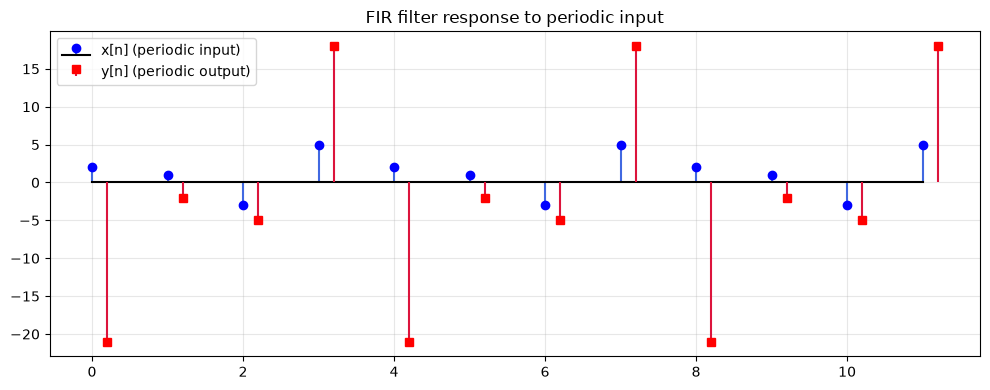

In [2]:
# Response to periodic input
x_period=np.array([2.,1.,-3.,5.])  # one period, L=4
b2=np.array([1.,-4.,1.])          # filter coefficients
L=4

X=np.fft.fft(x_period)
H_L=np.fft.fft(b2,L)  # frequency response at L frequencies
Y=H_L*X
y=np.fft.ifft(Y).real

print(f'x[0:3] = {x_period}')
print(f'b = {b2}')
print(f'Y = H*X = {Y.round(4)}')
print(f'y = IFFT(Y) = {y.round(4)}')

# Verify via circular convolution
b_padded=np.zeros(L); b_padded[:len(b2)]=b2
y_circ=np.fft.ifft(np.fft.fft(b_padded)*np.fft.fft(x_period)).real
print(f'Via circular conv: {y_circ.round(4)}')
print(f'Match? {np.allclose(y,y_circ)}')

# Verify via matrix equation
# y[0] = x[0]-4x[3]+x[2] = 2-20-3=-21... wait
# Filter: y[n]=x[n]-4x[n-1]+x[n-2]
# y[0]=x[0]-4*x[-1]+x[-2]=2-4*5+(-3)=-21+... hmm
# In periodic setting: y[0]=b[0]*x[0]+b[1]*x[3]+b[2]*x[2]=2-4*5+1*(-3)=2-20-3=-21
# Let's check directly
y_direct=np.zeros(L)
for n in range(L):
    for k in range(len(b2)):
        y_direct[n]+=b2[k]*x_period[(n-k)%L]
print(f'Direct circular: {y_direct}')

# Visualize
fig,ax=plt.subplots(figsize=(10,4))
n_plot=np.arange(3*L)
x_rep=np.tile(x_period,3)
y_rep=np.tile(y,3)
ax.stem(n_plot,x_rep,linefmt='royalblue',markerfmt='bo',basefmt='k',label='x[n] (periodic input)')
ax.stem(n_plot+0.2,y_rep,linefmt='crimson',markerfmt='rs',basefmt=' ',label='y[n] (periodic output)')
ax.set_title('FIR filter response to periodic input'); ax.legend(); ax.grid(True,alpha=0.3)
plt.tight_layout(); plt.show()

---
### 11. Cascaded Filters

Two FIR filters connected in series have system function:
$$H(z)=H_1(z)H_2(z)$$

**Proof:** Apply $x[n]=z^n$. Output of filter 1: $y^{(1)}[n]=H_1(z)z^n$. By linearity, output of filter 2: $y^{(2)}[n]=H_2(z)\cdot H_1(z)z^n=H(z)z^n$.

**Order doesn't matter:** $H_1H_2=H_2H_1$ (polynomial multiplication is commutative).

**Example:** $b^{(1)}=[1,2,2,1]^T$ and $b^{(2)}=[1,-4,1]^T$:
$$(1+2z^{-1}+2z^{-2}+z^{-3})(1-4z^{-1}+z^{-2})=1-2z^{-1}-5z^{-2}-5z^{-3}-2z^{-4}+z^{-5}$$


b1 = [1 2 2 1]
b2 = [ 1 -4  1]
b1 * b2 (cascade) = [ 1 -2 -5 -5 -2  1]
Expected: [1,-2,-5,-5,-2,1]
b2 * b1 = [ 1 -2 -5 -5 -2  1]  (same? True)

Max diff (cascade vs direct): 1.78e-15


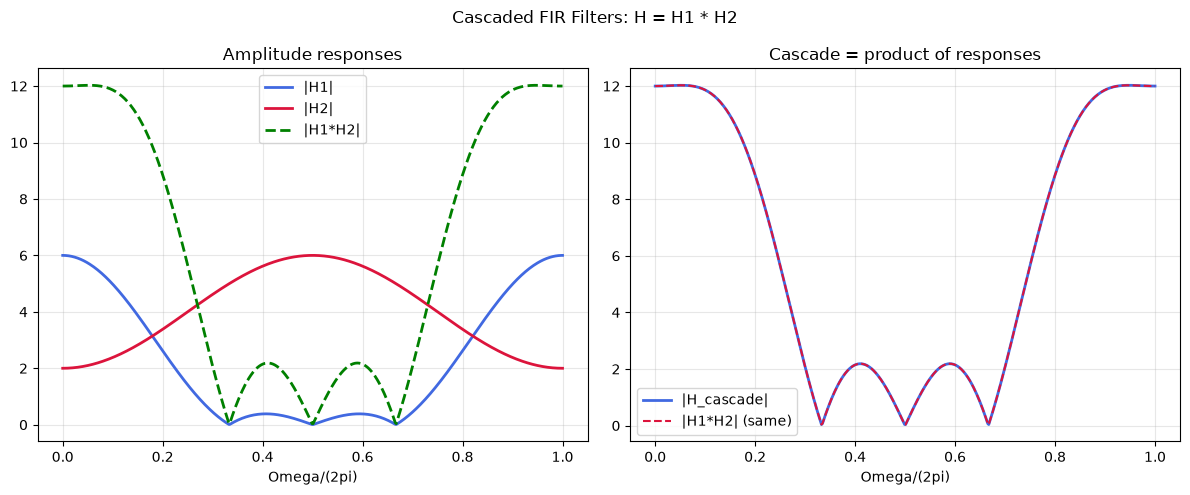

In [3]:
b1=np.array([1,2,2,1]); b2_c=np.array([1,-4,1])

# Cascade = convolution of coefficient vectors
b_cascade=np.convolve(b1,b2_c)
print(f'b1 = {b1}')
print(f'b2 = {b2_c}')
print(f'b1 * b2 (cascade) = {b_cascade}')
print('Expected: [1,-2,-5,-5,-2,1]')

# Verify order independence
b_cascade2=np.convolve(b2_c,b1)
print(f'b2 * b1 = {b_cascade2}  (same? {np.allclose(b_cascade,b_cascade2)})')

# Verify on test signal
n=np.arange(20)
x=np.cos(np.pi/4*n+0.3)
y1=np.convolve(b1,x); y12=np.convolve(b2_c,y1)[:len(n)]
y_direct=np.convolve(b_cascade,x)[:len(n)]
print(f'\nMax diff (cascade vs direct): {np.max(np.abs(y12-y_direct)):.2e}')

# Amplitude response of cascade
omega=np.linspace(0,2*np.pi,500)
H1=np.array([sum(b1[k]*np.exp(-1j*k*w) for k in range(len(b1))) for w in omega])
H2=np.array([sum(b2_c[k]*np.exp(-1j*k*w) for k in range(len(b2_c))) for w in omega])
H_prod=H1*H2
H_full=np.array([sum(b_cascade[k]*np.exp(-1j*k*w) for k in range(len(b_cascade))) for w in omega])

fig,axes=plt.subplots(1,2,figsize=(12,5))
axes[0].plot(omega/(2*np.pi),np.abs(H1),'royalblue',lw=2,label='|H1|')
axes[0].plot(omega/(2*np.pi),np.abs(H2),'crimson',lw=2,label='|H2|')
axes[0].plot(omega/(2*np.pi),np.abs(H_prod),'green',lw=2,ls='--',label='|H1*H2|')
axes[0].set_title('Amplitude responses'); axes[0].legend(); axes[0].grid(True,alpha=0.3)
axes[1].plot(omega/(2*np.pi),np.abs(H_full),'royalblue',lw=2,label='|H_cascade|')
axes[1].plot(omega/(2*np.pi),np.abs(H_prod),'crimson',lw=1.5,ls='--',label='|H1*H2| (same)')
axes[1].set_title('Cascade = product of responses'); axes[1].legend(); axes[1].grid(True,alpha=0.3)
for ax in axes: ax.set_xlabel('Omega/(2pi)')
plt.suptitle('Cascaded FIR Filters: H = H1 * H2', fontsize=12)
plt.tight_layout(); plt.show()

---
## Summary

| Input | Output |
|---|---|
| $r^n\cos(\Omega_0 n+\phi)$ | $|H(re^{j\Omega_0})|\,r^n\cos(\Omega_0 n+\phi+\angle H(re^{j\Omega_0}))$ |
| Periodic $x$, period $L$ | $Y[k]=H(e^{j2\pi k/L})X[k]$ |
| Cascade $H_1,H_2$ | $H(z)=H_1(z)H_2(z)$ |

### Mistakes to Avoid
1. For oscillating exponential, use $z=re^{j\Omega_0}$ (not just $e^{j\Omega_0}$).
2. When applying filter to a periodic input, zero-pad $b$ to length $L$ before taking FFT.
3. Cascade order doesn't matter for the system function, BUT it can affect numerical precision in practice.
